In [ ]:
import os
import torch
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader, Subset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

current_dir = os.getcwd()
if current_dir.endswith('notebooks'):
    PROJECT_ROOT = os.path.abspath(os.path.join(current_dir, '..'))
else:
    PROJECT_ROOT = current_dir

CROPPED_DATA_DIR = os.path.join(PROJECT_ROOT, 'data_cropped')

class CroppedToothbrushDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.samples = []
        
        defective_dir = os.path.join(data_dir, 'train', 'defective')
        if os.path.exists(defective_dir):
            for img_name in os.listdir(defective_dir):
                if img_name.endswith('.png'):
                    img_path = os.path.join(defective_dir, img_name)
                    mask_name = img_name.replace('.png', '_mask.png')
                    mask_path = os.path.join(data_dir, 'ground_truth', 'defective', mask_name)
                    self.samples.append((img_path, mask_path))
                    
        good_dir = os.path.join(data_dir, 'train', 'good')
        if os.path.exists(good_dir):
            for img_name in os.listdir(good_dir):
                if img_name.endswith('.png'):
                    img_path = os.path.join(good_dir, img_name)
                    self.samples.append((img_path, None))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if mask_path and os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 127).astype(np.float32)
        else:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)
            
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        return image, mask

def get_transforms(is_train=True, img_size=(256, 256)):
    if is_train:
        return A.Compose([
            A.Resize(height=img_size[0], width=img_size[1]),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.2),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(height=img_size[0], width=img_size[1]),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

BATCH_SIZE = 8
VALIDATION_SIZE = 15
RANDOM_SEED = 42

train_transforms = get_transforms(is_train=True)
valid_transforms = get_transforms(is_train=False)

base_train_dataset = CroppedToothbrushDataset(CROPPED_DATA_DIR, transform=train_transforms)
base_valid_dataset = CroppedToothbrushDataset(CROPPED_DATA_DIR, transform=valid_transforms)

indices = list(range(len(base_train_dataset)))
np.random.seed(RANDOM_SEED)
np.random.shuffle(indices)

train_size = len(base_train_dataset) - VALIDATION_SIZE
train_indices = indices[:train_size]
valid_indices = indices[train_size:]

train_dataset = Subset(base_train_dataset, train_indices)
valid_dataset = Subset(base_valid_dataset, valid_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Cropped dataset loaded! Training samples: {len(train_dataset)}, Validation: {len(valid_dataset)}")

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cropped dataset loaded! Training samples: 75, Validation: 15


In [ ]:
import segmentation_models_pytorch as smp
import time
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Computation device configured to: {device}")

model = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",     
    in_channels=3,                  
    classes=1                       
).to(device)

criterion = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def calculate_iou(pred_mask, true_mask, threshold=0.5):
    probs = torch.sigmoid(pred_mask)
    preds = (probs > threshold).float()
    intersection = (preds * true_mask).sum(dim=(2, 3))
    union = preds.sum(dim=(2, 3)) + true_mask.sum(dim=(2, 3)) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

EPOCHS = 40
best_valid_iou = 0.0

os.makedirs('../submission', exist_ok=True)
print("Starting the professional training loop on CROPPED data...")

for epoch in range(EPOCHS):
    start_time = time.time()
    
    model.train()
    train_loss, train_iou = 0.0, 0.0
    
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        if masks.dim() == 3:
            masks = masks.unsqueeze(1)
            
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_iou += calculate_iou(outputs, masks) * images.size(0)
        
    train_loss = train_loss / len(train_loader.dataset)
    train_iou = train_iou / len(train_loader.dataset)
    
    model.eval()
    valid_loss, valid_iou = 0.0, 0.0
    
    with torch.no_grad():
        for images, masks in valid_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            if masks.dim() == 3:
                masks = masks.unsqueeze(1)
                
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            valid_loss += loss.item() * images.size(0)
            valid_iou += calculate_iou(outputs, masks) * images.size(0)
            
    valid_loss = valid_loss / len(valid_loader.dataset)
    valid_iou = valid_iou / len(valid_loader.dataset)
    
    if valid_iou > best_valid_iou:
        best_valid_iou = valid_iou
        torch.save(model.state_dict(), '../submission/weights.pth')
        saved_msg = " -> BEST IoU MODEL SAVED!"
    else:
        saved_msg = ""
        
    end_time = time.time()
    epoch_mins = int((end_time - start_time) / 60)
    epoch_secs = int((end_time - start_time) % 60)
    
    print(f"Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s")
    print(f"\tTrain Loss: {train_loss:.4f} | Train IoU: {train_iou:.4f}")
    print(f"\tVal. Loss: {valid_loss:.4f} | Val. IoU: {valid_iou:.4f}{saved_msg}")

print("Training on cropped dataset completed successfully!")

Computation device configured to: cpu
Starting the professional training loop on CROPPED data...
Epoch: 01 | Time: 1m 9s
	Train Loss: 0.9584 | Train IoU: 0.0213
	Val. Loss: 0.9564 | Val. IoU: 0.0223 -> BEST IoU MODEL SAVED!
Epoch: 02 | Time: 1m 6s
	Train Loss: 0.7907 | Train IoU: 0.0356
	Val. Loss: 0.9945 | Val. IoU: 0.0000
Epoch: 03 | Time: 1m 9s
	Train Loss: 0.9167 | Train IoU: 0.1070
	Val. Loss: 0.8975 | Val. IoU: 0.0368 -> BEST IoU MODEL SAVED!
Epoch: 04 | Time: 1m 8s
	Train Loss: 0.7966 | Train IoU: 0.3481
	Val. Loss: 0.9102 | Val. IoU: 0.0446 -> BEST IoU MODEL SAVED!
Epoch: 05 | Time: 1m 9s
	Train Loss: 0.8839 | Train IoU: 0.1601
	Val. Loss: 0.8066 | Val. IoU: 0.6250 -> BEST IoU MODEL SAVED!
Epoch: 06 | Time: 1m 6s
	Train Loss: 0.7105 | Train IoU: 0.4001
	Val. Loss: 0.9269 | Val. IoU: 0.1611
Epoch: 07 | Time: 1m 8s
	Train Loss: 0.7921 | Train IoU: 0.3518
	Val. Loss: 0.7852 | Val. IoU: 0.1115
Epoch: 08 | Time: 1m 5s
	Train Loss: 0.6123 | Train IoU: 0.6016
	Val. Loss: 0.6612 | Val.

Ładowanie najlepszych wag modelu z dysku...


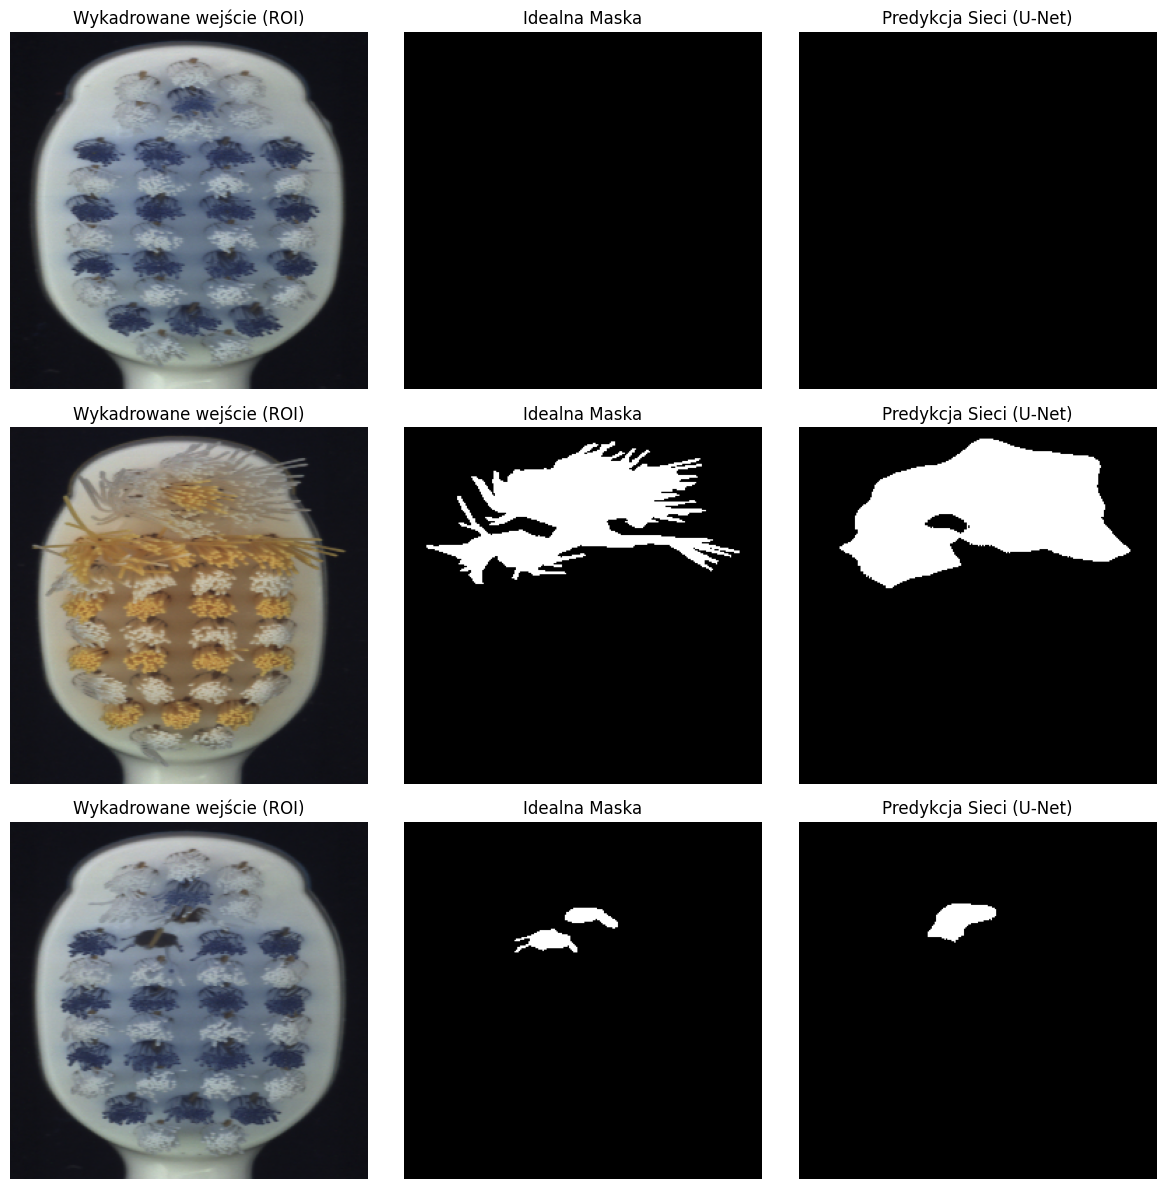

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_cropped_predictions(model, dataloader, device, num_samples=3):
    print("Ładowanie najlepszych wag modelu z dysku...")
    model.load_state_dict(torch.load('../submission/weights.pth', weights_only=True))
    model.eval()
    
    images, true_masks = next(iter(dataloader))
    images = images.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        
    images_np = images.cpu().numpy()
    true_masks_np = true_masks.cpu().numpy()
    preds_np = preds.cpu().numpy()
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    
    for i in range(min(num_samples, len(images))):
        img = np.transpose(images_np[i], (1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Wykadrowane wejście (ROI)")
        axes[i, 0].axis('off')
        
        true_mask = np.squeeze(true_masks_np[i])
        axes[i, 1].imshow(true_mask, cmap='gray')
        axes[i, 1].set_title("Idealna Maska")
        axes[i, 1].axis('off')
        
        pred_mask = np.squeeze(preds_np[i])
        axes[i, 2].imshow(pred_mask, cmap='gray')
        axes[i, 2].set_title("Predykcja Sieci (U-Net)")
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

visualize_cropped_predictions(model, valid_loader, device, num_samples=3)